In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('gurgaon_properties_cleaned_v2.csv')

In [3]:
df.head()

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,house,independent,sector 11,4.00,19753.0,2025.0,Built Up area: 225 (188.13 sq.m.)Carpet area: ...,5,4,1,...,NaN,225.0,180.0,0,0,0,0,0,1,0
1,flat,indiabulls enigma,sector 110,3.30,9850.0,3350.0,Super Built up area 3350(311.23 sq.m.),4,5,3,...,3350.0,NaN,NaN,0,1,0,0,0,1,101
2,flat,puri emerald bay,sector 104,2.30,9387.0,2450.0,Super Built up area 2450(227.61 sq.m.),3,4,3+,...,2450.0,NaN,NaN,0,1,0,0,0,1,101
3,house,nirvana cedar crest,sector 50,3.99,8866.0,4500.0,Plot area 4500(418.06 sq.m.),4,5,3+,...,NaN,4500.0,NaN,0,1,0,1,0,0,112
4,flat,bptp terra,sector 37,1.45,8006.0,1811.0,Super Built up area 1811(168.25 sq.m.)Built Up...,3,3,3,...,1811.0,1711.0,1611.0,0,0,0,0,0,1,149


In [24]:
df.shape

(3753, 23)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3757 entries, 0 to 3756
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   property_type        3757 non-null   object 
 1   society              3756 non-null   object 
 2   sector               3757 non-null   object 
 3   price                3739 non-null   float64
 4   price_per_sqft       3739 non-null   float64
 5   area                 3739 non-null   float64
 6   areaWithType         3757 non-null   object 
 7   bedRoom              3757 non-null   int64  
 8   bathroom             3757 non-null   int64  
 9   balcony              3757 non-null   object 
 10  floorNum             3737 non-null   float64
 11  facing               2681 non-null   object 
 12  agePossession        3757 non-null   object 
 13  super_built_up_area  1885 non-null   float64
 14  built_up_area        1745 non-null   float64
 15  carpet_area          1906 non-null   f

In [9]:
df.duplicated().sum()

np.int64(4)

In [12]:
df.drop_duplicates(inplace=True)

### property_type

<Axes: xlabel='property_type'>

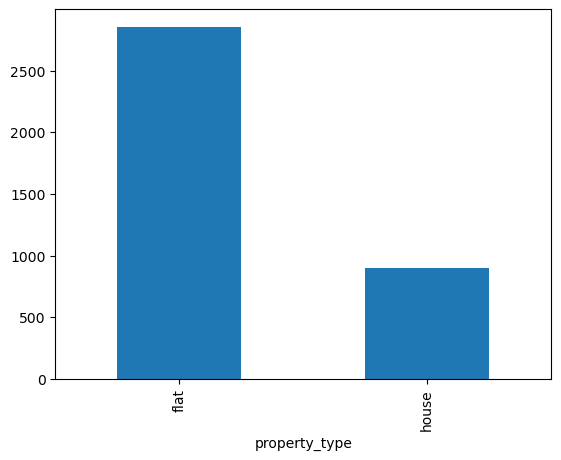

In [13]:
df['property_type'].value_counts().plot(kind='bar',)

#### Observations

- Flats are in majority(75 percent) and there are less number of houses(~25 percent)
- No missing values

### society

In [14]:
df['society'].value_counts()

society
independent                                    519
tulip violet                                    75
ss the leaf                                     73
dlf new town heights                            42
shapoorji pallonji joyville gurugram            42
                                              ... 
secter 16a daultabad faridabad house no 313      1
shri shyam residency                             1
chintamani                                       1
imt view society                                 1
bhim nagar, sector 6                             1
Name: count, Length: 704, dtype: int64

In [34]:
df[df['society']!='independent']['society'].value_counts(normalize=True).cumsum().head(76)

society
tulip violet                            0.023198
ss the leaf                             0.045778
dlf new town heights                    0.058769
shapoorji pallonji joyville gurugram    0.071760
signature global park                   0.082586
                                          ...   
the close north                         0.487782
puri emerald bay                        0.491803
unitech uniworld resorts                0.495515
ireo the corridors                      0.499227
mvn athens                              0.502938
Name: proportion, Length: 76, dtype: float64

In [25]:
society_counts = df['society'].value_counts()

# Frequency distribution for societies
frequency_bins = {
    "Very High (>100)": (society_counts > 100).sum(),
    "High (50-100)": ((society_counts >= 50) & (society_counts <= 100)).sum(),
    "Average (10-49)": ((society_counts >= 10) & (society_counts < 50)).sum(),
    "Low (2-9)": ((society_counts > 1) & (society_counts < 10)).sum(),
    "Very Low (1)": (society_counts == 1).sum()
}
frequency_bins

{'Very High (>100)': np.int64(1),
 'High (50-100)': np.int64(2),
 'Average (10-49)': np.int64(92),
 'Low (2-9)': np.int64(282),
 'Very Low (1)': np.int64(327)}

<Axes: xlabel='society'>

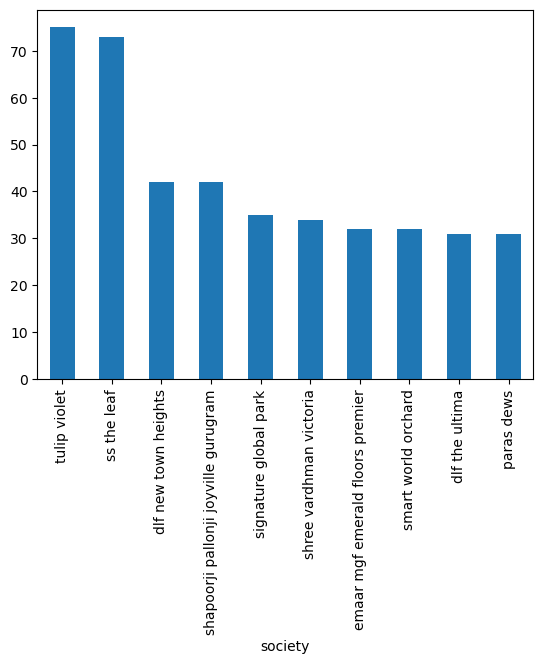

In [27]:
# top 10 socities
df[df['society'] != 'independent']['society'].value_counts().head(10).plot(kind='bar')

In [28]:
df['society'].isnull().sum()

np.int64(1)

In [29]:
df[df['society'].isnull()]

,property_type,society,sector,price,price_per_sqft,area,areaWithType,bedRoom,bathroom,balcony,...,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
1017,flat,NaN,sector 78,0.6,3692.0,1625.0,Built Up area: 1625 (150.97 sq.m.),2,2,0,...,NaN,1625.0,NaN,0,0,0,0,0,1,0


#### Observations

- Around 13% properties comes under independent tag.
- There are 675 societies. 
- The top 75 societies have 50 percent of the preperties and the rest 50 percent of the properties come under the remaining 600 societies
    - Very High (>100): Only 1 society has more than 100 listings.
    - High (50-100): 2 societies have between 50 to 100 listings.
    - Average (10-49): 92 societies fall in this range with 10 to 49 listings each.
    - Low (2-9): 282 societies have between 2 to 9 listings.
    - Very Low (1): A significant number, 327 societies, have only 1 listing.
- 1 missing value

### sector

In [30]:
# unique sectors
df['sector'].value_counts().shape

(96,)

<Axes: xlabel='sector'>

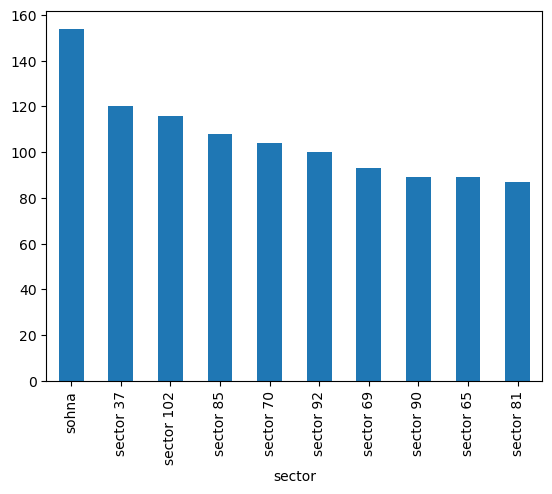

In [31]:
# top 10 sectors
df['sector'].value_counts().head(10).plot(kind='bar')

In [32]:
# Frequency distribution for sectors
sector_counts = df['sector'].value_counts()

sector_frequency_bins = {
    "Very High (>100)": (sector_counts > 100).sum(),
    "High (50-100)": ((sector_counts >= 50) & (sector_counts <= 100)).sum(),
    "Average (10-49)": ((sector_counts >= 10) & (sector_counts < 50)).sum(),
    "Low (2-9)": ((sector_counts > 1) & (sector_counts < 10)).sum(),
    "Very Low (1)": (sector_counts == 1).sum()
}

sector_frequency_bins

{'Very High (>100)': np.int64(5),
 'High (50-100)': np.int64(25),
 'Average (10-49)': np.int64(54),
 'Low (2-9)': np.int64(12),
 'Very Low (1)': np.int64(0)}

#### Observations

- There are a total of 104 unique sectors in the dataset.
- Frequency distribution of sectors:
    - Very High (>100): 5 sectors have more than 100 listings.
    - High (50-100): 25 sectors have between 50 to 100 listings.
    - Average (10-49): A majority, 54 sectors, fall in this range with 10 to 49 listings each.
    - Low (2-9): 12 sectors have between 2 to 9 listings.
    - Very Low (1): Interestingly, there are no sectors with only 1 listing.

### Price

In [35]:

df['price'].isnull().sum()

np.int64(18)

In [36]:
df['price'].describe()

count    3735.000000
mean        2.529430
std         2.973415
min         0.070000
25%         0.940000
50%         1.520000
75%         2.750000
max        31.500000
Name: price, dtype: float64

<Axes: xlabel='price', ylabel='Count'>

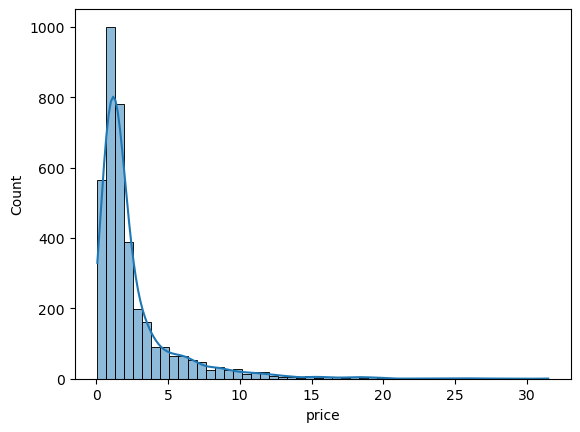

In [40]:
sns.histplot(df['price'], bins=50, kde=True)

<Axes: xlabel='price'>

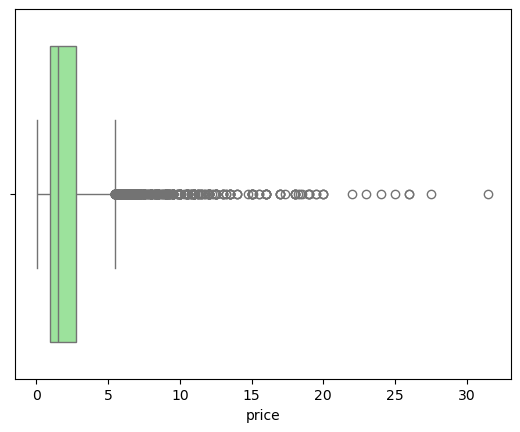

In [45]:
sns.boxplot(x=df['price'],color='lightgreen')

#### Observations
- Descriptive Statistics:

    - Count: There are 3,735 non-missing price entries.
    - Mean Price: The average price is approximately 2.52 crores.
    - Median Price: The median (or 50th percentile) price is 1.52 crores.
    - Standard Deviation: The prices have a standard deviation of 2.97, indicating variability in the prices.
    - Range: Prices range from a minimum of 0.07 crores to a maximum of 31.5 crores.
    - IQR: The interquartile range (difference between 75th and 25th percentile) is from 0.94 crores to 2.75 crores.


- Visualizations:

    - Distribution: The histogram indicates that most properties are priced in the lower range (below 5 crores), with a few properties going beyond 10 crores.
    - Box Plot: The box plot showcases the spread of the data and potential outliers. Properties priced above approximately 10 crores might be considered outliers as they lie beyond the upper whisker of the box plot.
 

- Missing Values: There are 17 missing values in the price column.

In [46]:
# Skewness and Kurtosis
skewness = df['price'].skew()
kurtosis = df['price'].kurt()

print(skewness,kurtosis)

3.27242655025514 14.894088434644125


**Skewness**: The price distribution has a skewness of approximately 3.28, indicating a positive skew. This means that the distribution tail is skewed to the right, which aligns with our observation from the histogram where most properties have prices on the lower end with a few high-priced properties.

**Kurtosis**: The kurtosis value is approximately 14.93. A kurtosis value greater than 3 indicates a distribution with heavier tails and more outliers compared to a normal distribution.

In [47]:
# Quantile Analysis
quantiles = df['price'].quantile([0.01, 0.05, 0.95, 0.99])

quantiles

0.01     0.250
0.05     0.370
0.95     8.500
0.99    15.364
Name: price, dtype: float64

*Quantile Analysis*:

- 1% Quantile: Only 1% of properties are priced below 0.25 crores.
- 5% Quantile: 5% of properties are priced below 0.37 crores.
- 95% Quantile: 95% of properties are priced below 8.5 crores.
- 99% Quantile: 99% of properties are priced below 15.26 crores, indicating that very few properties are priced above this value.

In [48]:
# Identify potential outliers using IQR method
Q1 = df['price'].describe()['25%']
Q3 = df['price'].describe()['75%']
IQR = Q3 - Q1

IQR

np.float64(1.81)

In [49]:
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)

-1.775 5.465


In [50]:
outliers = df[(df['price'] < lower_bound) | (df['price'] > upper_bound)]
outliers.shape

(435, 23)

In [51]:
outliers['price'].describe()

count    435.000000
mean       9.198575
std        4.051939
min        5.490000
25%        6.420000
50%        8.000000
75%       10.555000
max       31.500000
Name: price, dtype: float64

Outliers Analysis (using IQR method):

- Based on the IQR method, there are 435 properties considered as outliers.
- These outliers have an average price of approximately 9.19 crores.
- The range for these outliers is from 5.46 crores to 31.5 crores.

<Axes: xlabel='price'>

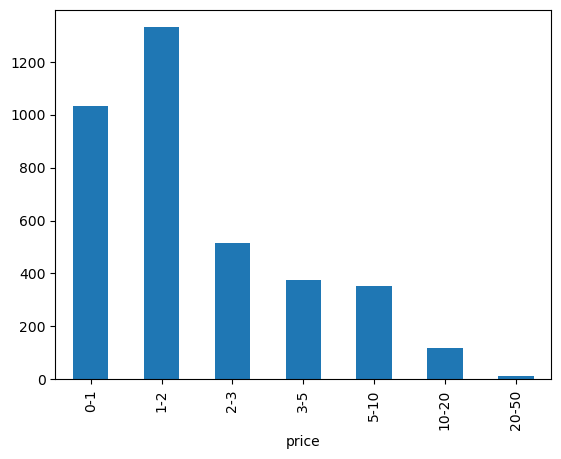

In [52]:
# price binning
bins = [0, 1, 2, 3, 5, 10, 20, 50]
bin_labels = ["0-1", "1-2", "2-3", "3-5", "5-10", "10-20", "20-50"]
pd.cut(df['price'], bins=bins, labels=bin_labels, right=False).value_counts().sort_index().plot(kind='bar')

- The majority of properties are priced in the "1-2 crores" and "2-3 crores" ranges.
- There's a significant drop in the number of properties priced above "5 crores."

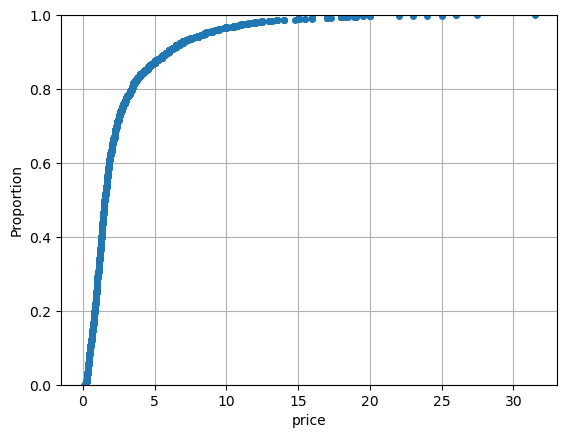

In [70]:
# ecdf plot
sns.ecdfplot(df['price'],linewidth=1,marker='o',markersize=4,linestyle='None')
plt.grid()

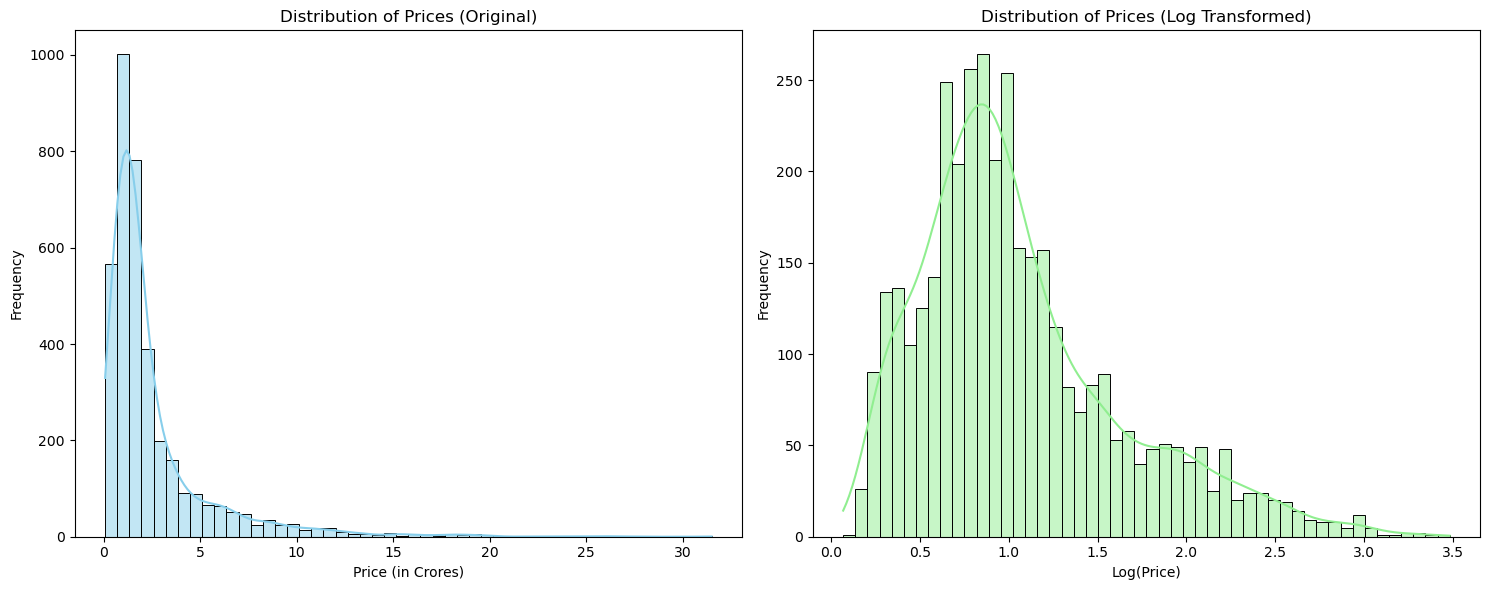

In [71]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.histplot(df['price'], kde=True, bins=50, color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['price']), kde=True, bins=50, color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [72]:
skewness = np.log1p(df['price']).skew()
kurtosis = np.log1p(df['price']).kurt()

print(skewness,kurtosis)

1.0666935898536283 0.9436450739248912


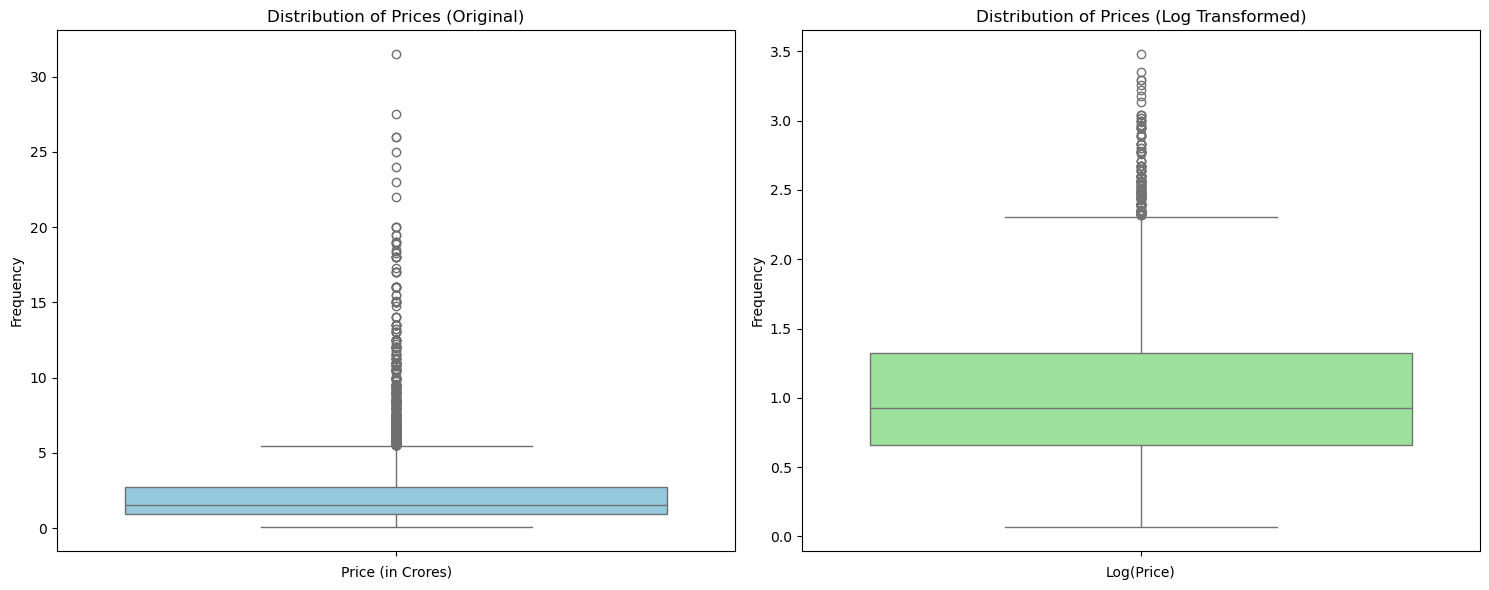

In [73]:
plt.figure(figsize=(15, 6))

# Distribution plot without log transformation
plt.subplot(1, 2, 1)
sns.boxplot(df['price'], color='skyblue')
plt.title('Distribution of Prices (Original)')
plt.xlabel('Price (in Crores)')
plt.ylabel('Frequency')

# Distribution plot with log transformation
plt.subplot(1, 2, 2)
sns.boxplot(np.log1p(df['price']), color='lightgreen')
plt.title('Distribution of Prices (Log Transformed)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Price_per_sqft

In [74]:
df['price_per_sqft'].isnull().sum()

np.int64(18)

In [75]:
df['price_per_sqft'].describe()

count      3735.000000
mean      13936.505489
std       23252.588408
min           2.000000
25%        6809.500000
50%        9020.000000
75%       13888.000000
max      600000.000000
Name: price_per_sqft, dtype: float64

<Axes: xlabel='price_per_sqft', ylabel='Count'>

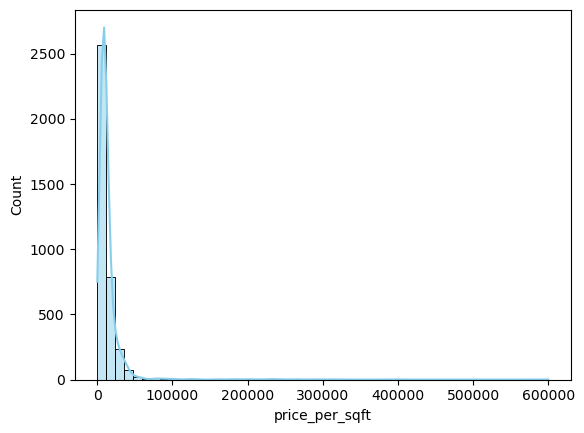

In [76]:
sns.histplot(df['price_per_sqft'],bins=50,color='skyblue',kde=True)

<Axes: xlabel='price_per_sqft'>

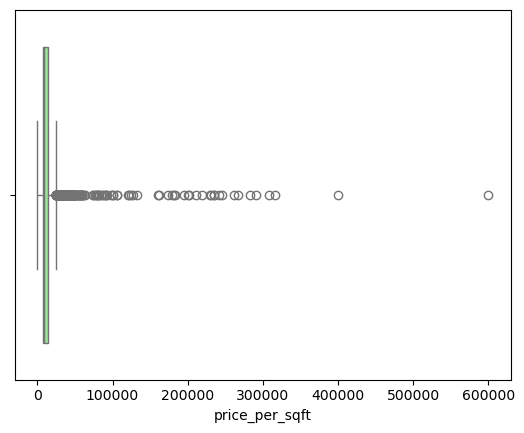

In [78]:
sns.boxplot(x=df['price_per_sqft'], color='lightgreen')

#### Observations

- Potential Outliers
- Right Skewed
- 17 missing values

### bedRoom

In [79]:
df['bedRoom'].isnull().sum()

np.int64(0)

In [80]:
df['bedRoom'].value_counts()

bedRoom
3     1515
2      958
4      679
5      217
1      130
6       78
9       41
8       32
7       29
12      28
10      21
16      12
13       4
19       2
18       2
11       2
21       1
14       1
20       1
Name: count, dtype: int64

<Axes: xlabel='bedRoom'>

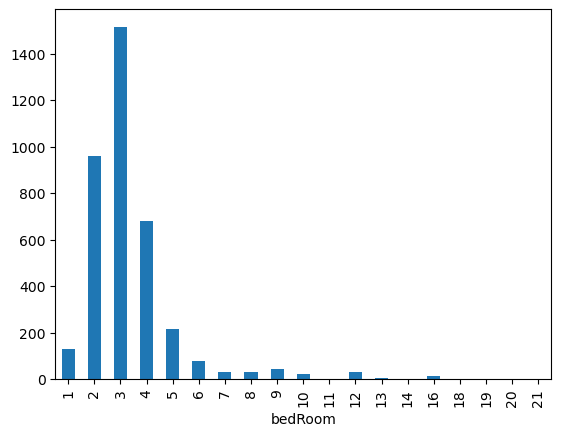

In [81]:
df['bedRoom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='count'>

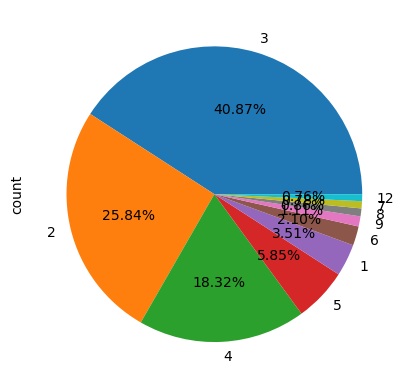

In [97]:
df['bedRoom'].value_counts().head(10).plot(kind='pie',autopct='%0.2f%%')

### bathroom

In [95]:
df['bathroom'].isnull().sum()

np.int64(0)

<Axes: xlabel='bathroom'>

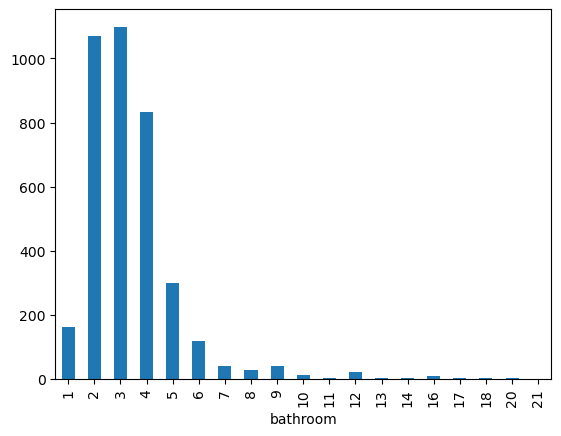

In [96]:
df['bathroom'].value_counts().sort_index().plot(kind='bar')

<Axes: ylabel='count'>

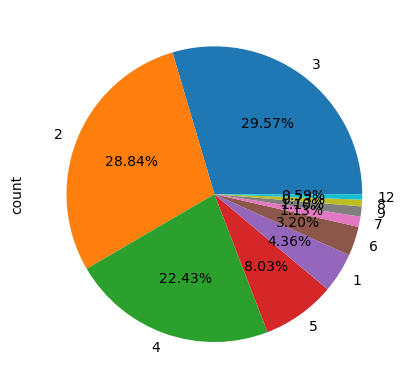

In [99]:
df['bathroom'].value_counts().head(10).plot(kind='pie',autopct='%0.2f%%')

### balcony

In [100]:
df['balcony'].isnull().sum()

np.int64(0)

<Axes: xlabel='balcony'>

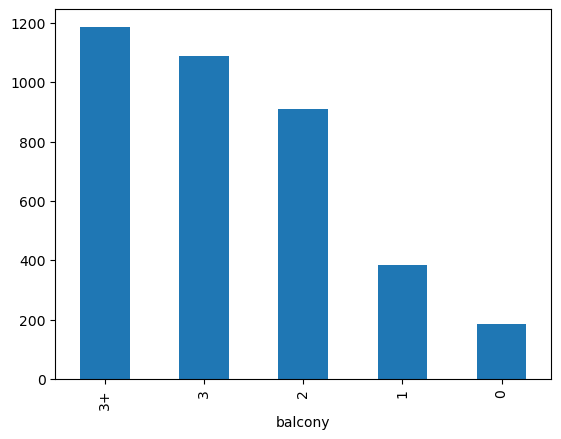

In [101]:
df['balcony'].value_counts().plot(kind='bar')

<Axes: ylabel='count'>

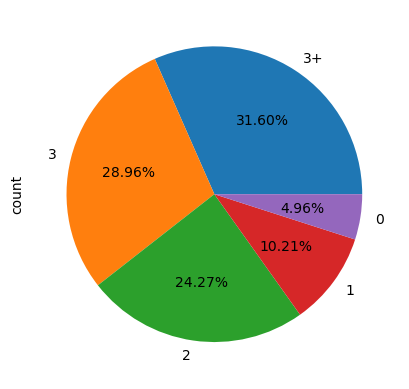

In [102]:
df['balcony'].value_counts().head().plot(kind='pie',autopct='%0.2f%%')

### floorNum

In [103]:
df.iloc[:,10:].head()

,floorNum,facing,agePossession,super_built_up_area,built_up_area,carpet_area,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,2.0,North-East,Undefined,NaN,225.0,180.0,0,0,0,0,0,1,0
1,7.0,East,Relatively New,3350.0,NaN,NaN,0,1,0,0,0,1,101
2,10.0,North-East,Moderately Old,2450.0,NaN,NaN,0,1,0,0,0,1,101
3,4.0,North-East,New Property,NaN,4500.0,NaN,0,1,0,1,0,0,112
4,8.0,South-East,Relatively New,1811.0,1711.0,1611.0,0,0,0,0,0,1,149


In [104]:
df['floorNum'].isnull().sum()

np.int64(20)

In [105]:
df['floorNum'].describe()

count    3733.000000
mean        6.740691
std         6.014563
min         0.000000
25%         2.000000
50%         5.000000
75%        10.000000
max        51.000000
Name: floorNum, dtype: float64

<Axes: xlabel='floorNum'>

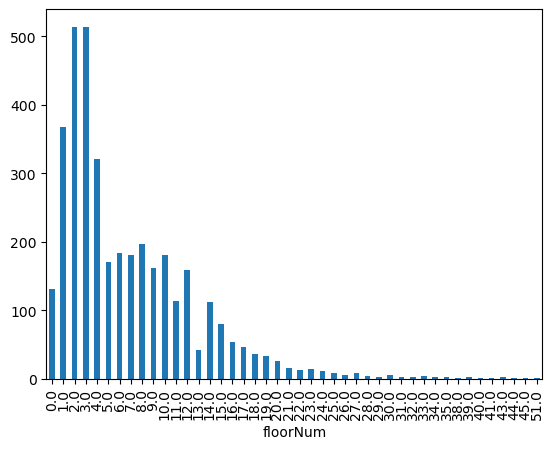

In [106]:
df['floorNum'].value_counts().sort_index().plot(kind='bar')

<Axes: xlabel='floorNum'>

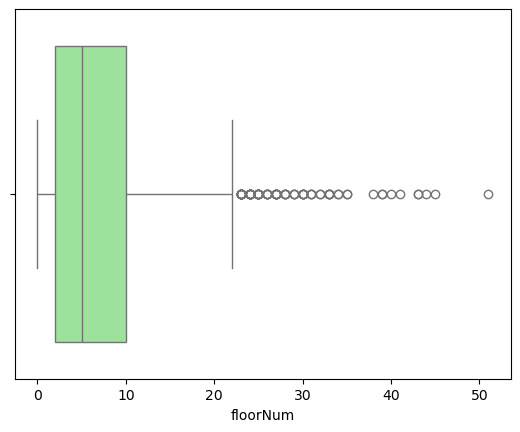

In [108]:
sns.boxplot(x=df['floorNum'], color='lightgreen')

### observations
- The majority of the properties lie between the ground floor (0) and the 25th floor.
- Floors 1 to 4 are particularly common, with the 3rd floor being the most frequent.
- There are a few properties located at higher floors, but their frequency is much lower.
- The box plot reveals that the majority of the properties are concentrated around the lower floors. The interquartile range (IQR) lies between approximately the 2nd and 10th floors.
- Data points beyond the "whiskers" of the box plot, especially on the higher side, indicate potential outliers.

### facing


In [115]:
df[df['facing']=='NA'].shape

(1073, 23)

In [116]:
df['facing'].value_counts()

facing
NA            1073
East           639
North-East     633
North          395
West           251
South          234
North-West     196
South-East     179
South-West     153
Name: count, dtype: int64

### agePossession

In [117]:
df['agePossession'].isnull().sum()

np.int64(0)

In [118]:
df['agePossession'].value_counts()

agePossession
Relatively New        1660
New Property           601
Moderately Old         579
Old Property           324
Undefined              320
Under Construction     269
Name: count, dtype: int64

### areas

In [119]:
# super built up area
df['super_built_up_area'].isnull().sum()

np.int64(1869)

In [120]:
df['super_built_up_area'].describe()

count     1884.000000
mean      1923.333094
std        765.423832
min         89.000000
25%       1474.250000
50%       1828.000000
75%       2215.000000
max      10000.000000
Name: super_built_up_area, dtype: float64

<Axes: xlabel='super_built_up_area', ylabel='Count'>

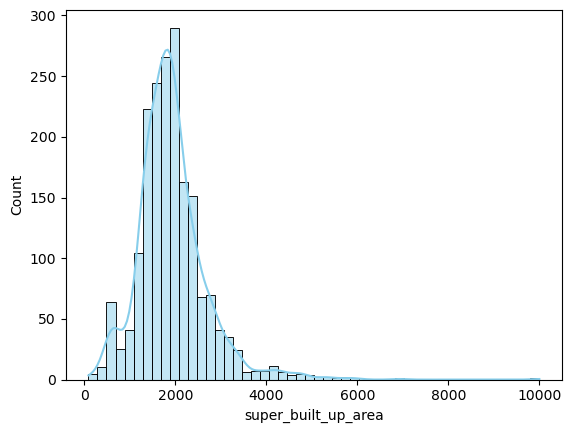

In [123]:
sns.histplot(df['super_built_up_area'].dropna(), bins=50, color='skyblue', kde=True)

<Axes: xlabel='super_built_up_area'>

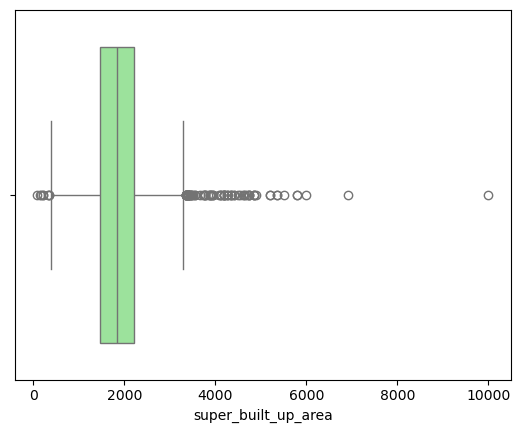

In [125]:
sns.boxplot(x=df['super_built_up_area'].dropna(), color='lightgreen')

- Most properties have a super built-up area ranging between approximately 1,000 sq.ft and 2,500 sq.ft.
- There are a few properties with a significantly larger area, leading to a right-skewed distribution.
- The interquartile range (IQR) lies between roughly 1,480 sq.ft and 2,215 sq.ft, indicating that the middle 50% of the properties fall within this range.
- There are several data points beyond the upper "whisker" of the box plot, indicating potential outliers. These are properties with an unusually large super built-up area.

In [126]:
df['built_up_area'].isnull().sum()

np.int64(2010)

In [127]:
df['built_up_area'].describe()

count      1743.000000
mean       2365.918835
std       17679.333733
min           2.000000
25%        1080.000000
50%        1642.000000
75%        2400.000000
max      737147.000000
Name: built_up_area, dtype: float64

<Axes: xlabel='built_up_area', ylabel='Count'>

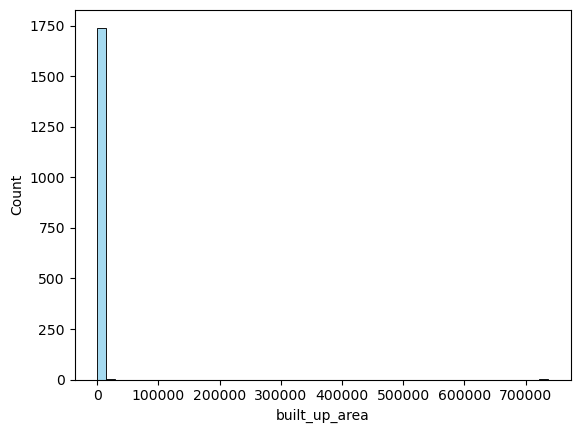

In [128]:
sns.histplot(df['built_up_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='built_up_area'>

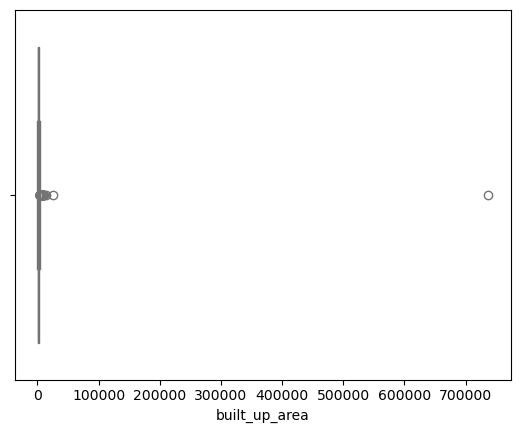

In [130]:
sns.boxplot(x=df['built_up_area'].dropna(), color='lightgreen')

- Most properties have a built-up area ranging roughly between 500 sq.ft and 3,500 sq.ft.
- There are very few properties with a much larger built-up area, leading to a highly right-skewed distribution.
- The box plot confirms the presence of significant outliers on the higher side. The data's interquartile range (IQR) is relatively compact, but the "whiskers" of the box plot are stretched due to the outliers.


The presence of extreme values, especially on the higher side, suggests that there may be outliers or data errors. This could also be due to some properties being exceptionally large, like a commercial complex or an entire building being listed.

In [131]:
# carpet area
df['carpet_area'].isnull().sum()

np.int64(1849)

In [132]:
df['carpet_area'].describe()

count      1904.000000
mean       2510.520067
std       22608.283984
min          15.000000
25%         824.000000
50%        1300.000000
75%        1791.750000
max      607936.000000
Name: carpet_area, dtype: float64

<Axes: xlabel='carpet_area', ylabel='Count'>

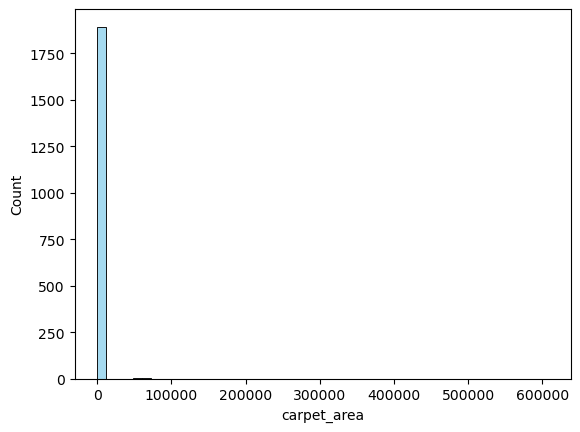

In [133]:
sns.histplot(df['carpet_area'].dropna(), bins=50, color='skyblue', kde=False)

<Axes: xlabel='carpet_area'>

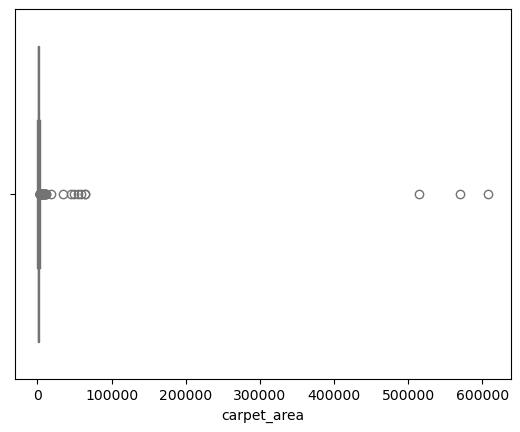

In [135]:
sns.boxplot(x=df['carpet_area'].dropna(), color='lightgreen')

In [136]:
df.iloc[:,16:]

,study room,servant room,store room,pooja room,others,furnishing_type,luxury_score
0,0,0,0,0,0,1,0
1,0,1,0,0,0,1,101
2,0,1,0,0,0,1,101
3,0,1,0,1,0,0,112
4,0,0,0,0,0,1,149
...,...,...,...,...,...,...,...
3752,0,0,0,0,0,1,28
3753,0,0,0,0,0,1,13
3754,0,0,0,0,0,1,51
3755,0,0,0,0,0,1,23


### additional rooms

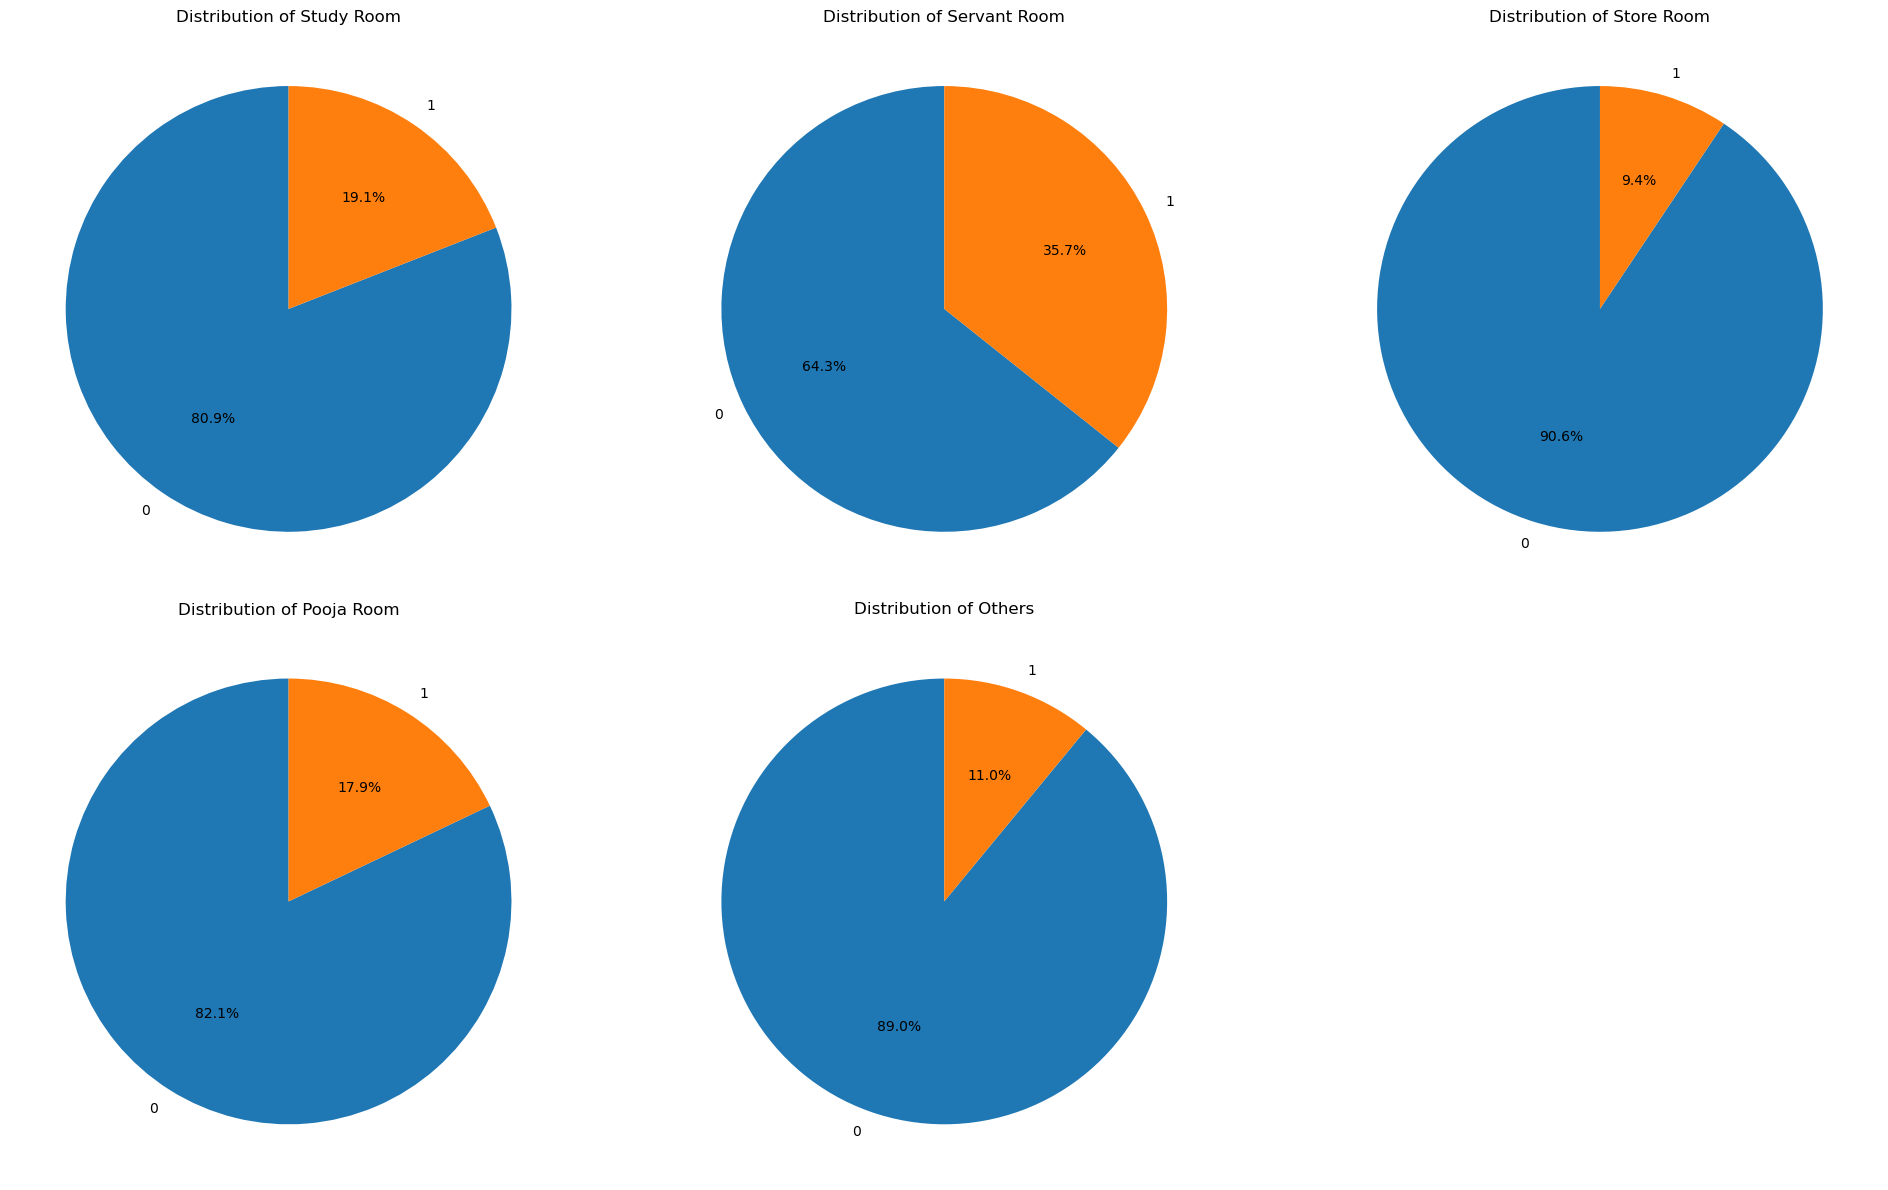

In [137]:
plt.figure(figsize=(20, 12))

# Create a subplot of pie charts for each room type
for idx, room in enumerate(['study room','servant room','store room','pooja room','others'], 1):
    ax = plt.subplot(2, 3, idx)
    df[room].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, ax=ax)
    plt.title(f'Distribution of {room.title()}')
    plt.ylabel('')

plt.tight_layout()
plt.show()

### furnishing_type

In [138]:
df['furnishing_type'].value_counts()

furnishing_type
1    2491
0    1056
2     206
Name: count, dtype: int64

<Axes: ylabel='count'>

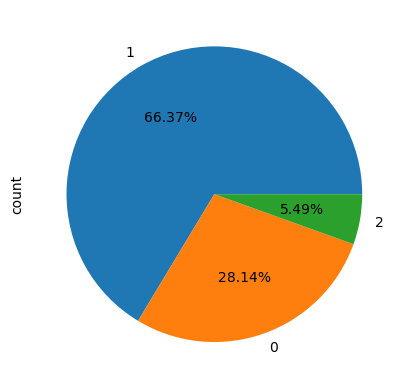

In [139]:
df['furnishing_type'].value_counts().plot(kind='pie',autopct='%0.2f%%')

### luxury score

In [140]:
df['luxury_score'].isnull().sum()

np.int64(0)

In [141]:
df['luxury_score'].describe()

count    3753.000000
mean       70.641354
std        53.071007
min         0.000000
25%        31.000000
50%        58.000000
75%       109.000000
max       174.000000
Name: luxury_score, dtype: float64

<Axes: xlabel='luxury_score', ylabel='Count'>

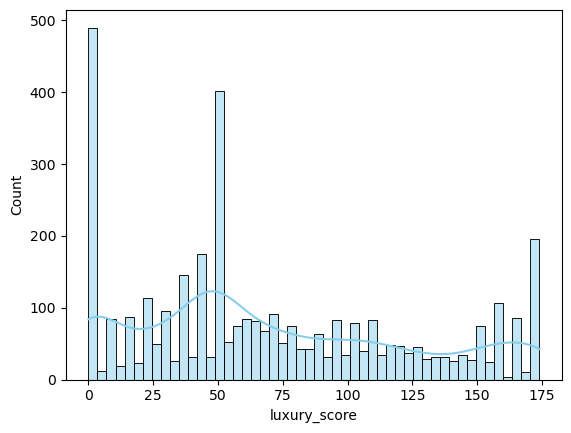

In [142]:
sns.histplot(df['luxury_score'], bins=50, color='skyblue', kde=True)

<Axes: xlabel='luxury_score'>

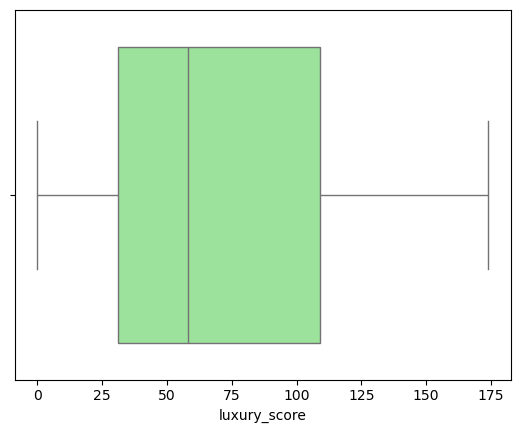

In [144]:
sns.boxplot(x=df['luxury_score'], color='lightgreen')